In [1]:
# ==========================================
# OLYMPICS DATA ANALYSIS (1976–2008)
# ==========================================

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.style.use("seaborn-v0_8")


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rushikeshhande0809/summerolympicmedals1976to2008-csv/SummerOlympicmedals1976to2008.csv


In [3]:
# 2️⃣ Load Dataset
data = pd.read_csv(
    "/kaggle/input/datasets/rushikeshhande0809/summerolympicmedals1976to2008-csv/SummerOlympicmedals1976to2008.csv",
    encoding="latin1"
)

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (15433, 11)


,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
0,Montreal,1976.0,Aquatics,Diving,3m springboard,"KÖHLER, Christa",Women,GDR,East Germany,W,Silver
1,Montreal,1976.0,Aquatics,Diving,3m springboard,"KOSENKOV, Aleksandr",Men,URS,Soviet Union,M,Bronze
2,Montreal,1976.0,Aquatics,Diving,3m springboard,"BOGGS, Philip George",Men,USA,United States,M,Gold
3,Montreal,1976.0,Aquatics,Diving,3m springboard,"CAGNOTTO, Giorgio Franco",Men,ITA,Italy,M,Silver
4,Montreal,1976.0,Aquatics,Diving,10m platform,"WILSON, Deborah Keplar",Women,USA,United States,W,Bronze


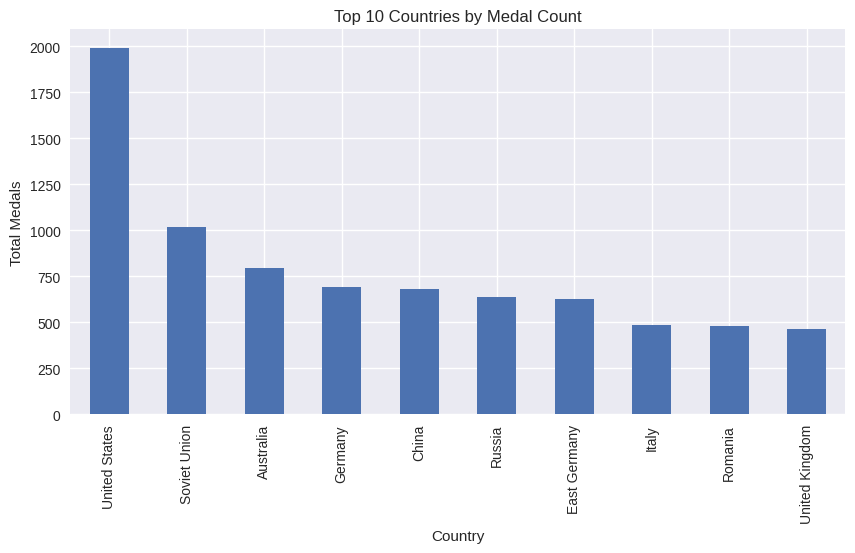

In [4]:
top_countries = data['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Medal Count")
plt.xlabel("Country")
plt.ylabel("Total Medals")
plt.show()

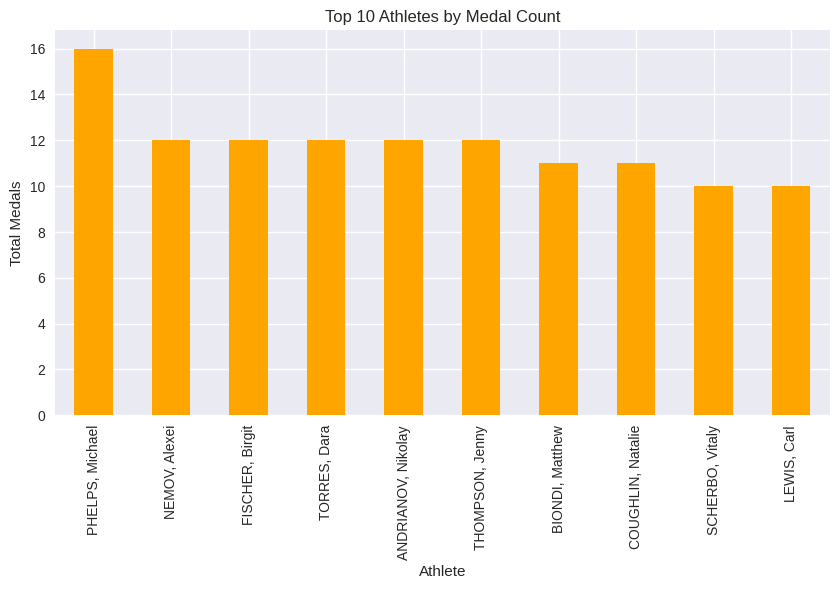

In [5]:
top_athletes = data['Athlete'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_athletes.plot(kind='bar', color='orange')
plt.title("Top 10 Athletes by Medal Count")
plt.xlabel("Athlete")
plt.ylabel("Total Medals")
plt.show()

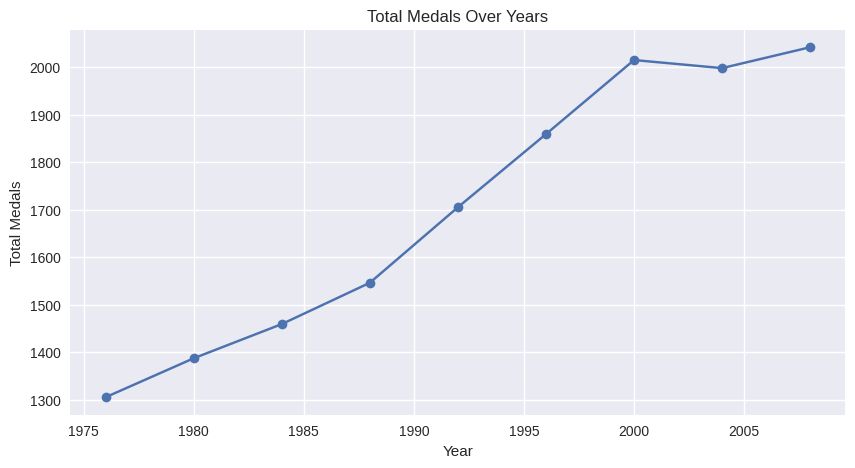

In [6]:
medals_year = data.groupby('Year')['Medal'].count()

plt.figure(figsize=(10,5))
plt.plot(medals_year.index, medals_year.values, marker='o')
plt.title("Total Medals Over Years")
plt.xlabel("Year")
plt.ylabel("Total Medals")
plt.grid(True)
plt.show()

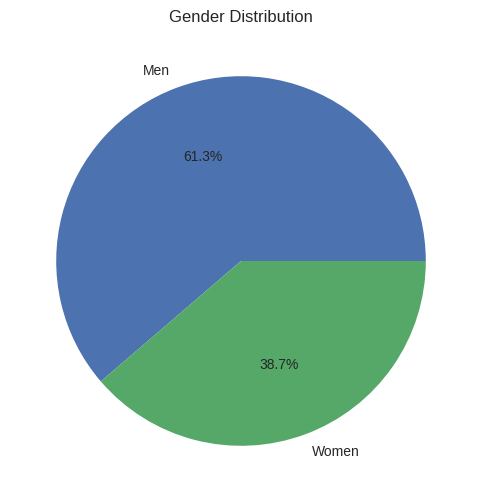

In [7]:
gender_dist = data['Gender'].value_counts()

plt.figure(figsize=(6,6))
gender_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

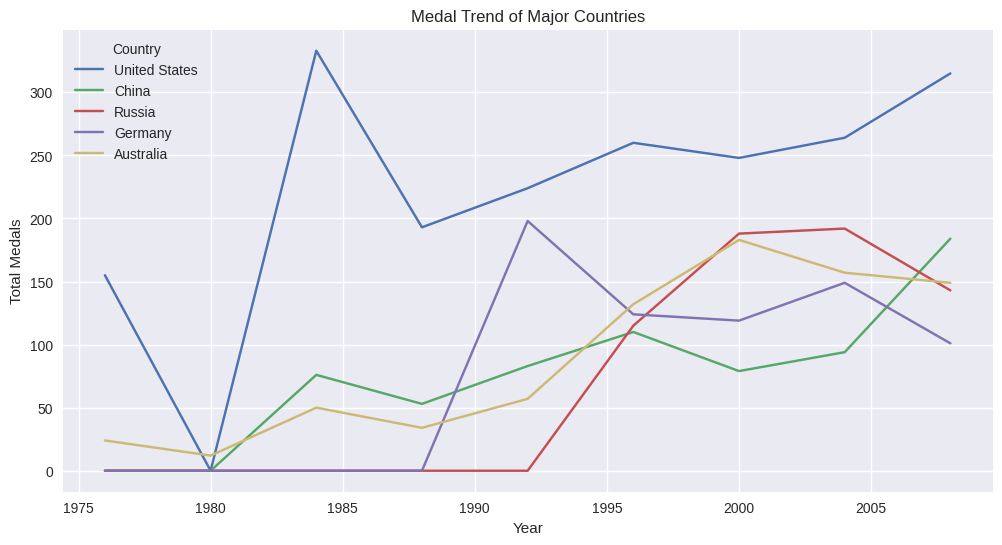

In [8]:
country_year = data.groupby(['Year','Country'])['Medal'].count().reset_index()

pivot = country_year.pivot(index='Year', columns='Country', values='Medal').fillna(0)

major_countries = ['United States','China','Russia','Germany','Australia']

pivot[major_countries].plot(figsize=(12,6))
plt.title("Medal Trend of Major Countries")
plt.ylabel("Total Medals")
plt.show()


In [9]:
year_country = data.groupby(['Year','Country'])['Medal'].count().reset_index()
top_each_year = year_country.sort_values(['Year','Medal'], ascending=[True,False])
top_each_year = top_each_year.groupby('Year').first()

top_each_year


,Country,Medal
Year,,
1976.0,Soviet Union,285
1980.0,Soviet Union,442
1984.0,United States,333
1988.0,Soviet Union,294
1992.0,United States,224
1996.0,United States,260
2000.0,United States,248
2004.0,United States,264
2008.0,United States,315


In [10]:
# ======================================
# MACHINE LEARNING - Predict Medal Type
# ======================================

df = data.copy()

# Encode Medal as target
le_medal = LabelEncoder()
df['Medal_Label'] = le_medal.fit_transform(df['Medal'])

# Encode categorical columns
le = LabelEncoder()
df['Sport'] = le.fit_transform(df['Sport'])
df['Gender'] = le.fit_transform(df['Gender'])
df['Country'] = le.fit_transform(df['Country'])

# Features and Target
X = df[['Sport','Gender','Country']]
y = df['Medal_Label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))


Accuracy: 0.37105831533477324

Confusion Matrix:
 [[1043  501    0    0]
 [ 892  647    0    0]
 [ 918  601    0    0]
 [   0    0    0   28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.37      0.68      0.47      1544
           1       0.37      0.42      0.39      1539
           2       0.00      0.00      0.00      1519
           3       1.00      1.00      1.00        28

    accuracy                           0.37      4630
   macro avg       0.43      0.52      0.47      4630
weighted avg       0.25      0.37      0.30      4630



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))

Accuracy: 0.5300215982721382

Confusion Matrix:
 [[887 391 266   0]
 [386 924 229   0]
 [460 444 615   0]
 [  0   0   0  28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.57      0.54      1544
           1       0.53      0.60      0.56      1539
           2       0.55      0.40      0.47      1519
           3       1.00      1.00      1.00        28

    accuracy                           0.53      4630
   macro avg       0.65      0.64      0.64      4630
weighted avg       0.53      0.53      0.53      4630

